In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from modules.mpo import FSM, MPO

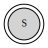

In [3]:
f = FSM()
f.draw()

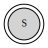

In [4]:
m = MPO()
m.draw()

In [23]:
m.get_site_symbol()

i

{(0, 0): 'I', (0, 1): 'B', (1, 2): 'C', (0, 2): 'D', (1, 1): 'A', (2, 2): 'I'}


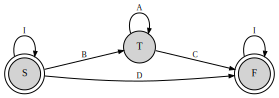

In [27]:
m.default()
print(m.transitions)
m.draw()

In [28]:
m.symbols

{'I': I, 'B': B, 'C': C, 'D': D, 'A': A}

In [29]:
m.transitions

{(0, 0): 'I', (0, 1): 'B', (1, 2): 'C', (0, 2): 'D', (1, 1): 'A', (2, 2): 'I'}

In [30]:
m.get_symbolic_table()

Matrix([
[I, B, D],
[0, A, C],
[0, 0, I]])

In [32]:
m.site

i

In [6]:
ising1 = MPO()

ising1.add_state(1)
ising1.add_state(2, True)

ising1.add_transition((0,0), 'I_1')
ising1.add_transition((0,1), 'X_1')
ising1.add_transition((1,2), 'X_1')
ising1.add_transition((0,2), 'Z_1')
ising1.add_transition((2,2), 'I_1')

In [9]:
ising2 = MPO()

ising2.add_state(1)
ising2.add_state(2, True)

ising2.add_transition((0,0), 'I_2')
ising2.add_transition((0,1), 'X_2')
ising2.add_transition((1,2), 'X_2')
ising2.add_transition((0,2), 'Z_2')
ising2.add_transition((2,2), 'I_2')

In [10]:
t1 = ising1.get_symbolic_table()
t2 = ising2.get_symbolic_table()

In [11]:
t1

Matrix([
[I_1, X_1, Z_1],
[  0,   0, X_1],
[  0,   0, I_1]])

In [12]:
t2

Matrix([
[I_2, X_2, Z_2],
[  0,   0, X_2],
[  0,   0, I_2]])

In [13]:
t1 @ t2

Matrix([
[I_1*I_2, I_1*X_2, I_1*Z_2 + X_1*X_2 + Z_1*I_2],
[      0,       0,                     X_1*I_2],
[      0,       0,                     I_1*I_2]])

In [24]:
t1.draw()

AttributeError: 'MutableDenseMatrix' object has no attribute 'draw'

In [ ]:
import sympy as sp

mat = sp.Matrix([[0,0], [0,0]])

t1.subs({ising1.symbols["0"]: mat})

In [ ]:
from sympy import Mul

expr = Mul(t1, t2, evaluate=False)
expr

In [ ]:
d = 2  # dimension of the Hilbert space
N = np.zeros((d, d))  # empty matrix
Id = np.eye(d)  # identity matrix
X = np.array([[0.0, 1.0], [1.0, 0.0]])  # pauli $\sigma_x$ matrix
Y = np.array([[0.0, -1j], [1j, 0.0]])  # pauli $\sigma_y$ matrix
Z = np.array([[1.0, 0.0], [0.0, -1.0]])  # pauli $\sigma_z$ matrix

In [ ]:
expr.table

In [ ]:
(t1*t2)

In [ ]:
t1*t2

In [ ]:
ising1.symbols

In [ ]:
t1.subs(ising1.symbols['I_1'], 0)


In [ ]:
import sympy as sp

d = 2                            # dimension of the Hilbert space
N = np.zeros((d,d))              # empty matrix
I = np.eye(d)                    # identity matrix
X = np.array([[0.,1.],[1.,0.]])  # pauli $\sigma_x$ matrix
Y = np.array([[0.,-1j],[1j,0.]]) # pauli $\sigma_y$ matrix
Z = np.array([[1.,0.],[0.,-1.]]) # pauli $\sigma_z$ matrix

Ns = sp.Matrix(N)
Is = sp.Matrix(I)
Xs = sp.Matrix(X)
Ys = sp.Matrix(Y)
Zs = sp.Matrix(Z)

res = t1.subs({ising1.symbols["I_1"]: Is, ising1.symbols["X_1"]: Xs, ising1.symbols["Z_1"]: Zs, ising1.symbols["0"]: Ns})
res = sp.Matrix(res).expand()
res

In [ ]:
print(t1.free_symbols)
for i in t1.free_symbols:
    print(i.shape)
print(t1.shape)
print(expr.free_symbols)
print(expr.shape)

In [ ]:
expr = t1 * t2
print(expr)

In [ ]:
i1is = ising1.symbols["I_1"]
i1ix = ising1.symbols["X_1"]
i1iz = ising1.symbols["Z_1"]
i1in = ising1.symbols["0"]

i2is = ising2.symbols["I_2"]
i2ix = ising2.symbols["X_2"]
i2iz = ising2.symbols["Z_2"]
i2in = ising2.symbols["0"]

res = expr.subs({i1is: Is, i1ix: Xs, i1iz : Zs, i1in: Ns,
                 i2is: Is, i2ix: Xs, i2iz : Zs, i2in: Ns})

res

In [ ]:
res[0]

In [ ]:
explicits = {} 
for i, e in enumerate(res):
    explicits[i] = e.as_explicit()

for i in explicits:
    res[i] = explicits[i]

In [ ]:
res

In [ ]:
from sympy import MatrixSymbol, Matrix

x1 = MatrixSymbol('x1', 2, 2)
x2 = MatrixSymbol('x2', 2, 2)
expr = (x1*x2**2)
expr

In [ ]:
x1_sub = Matrix([[0,1],[1,0]])
x2_sub = Matrix([[1,0],[0,1]])

expr.subs({x1: x1_sub, x2: x2_sub}).as_explicit()